<a href="https://colab.research.google.com/github/lauragragera/Procesos-Estocasticos/blob/main/MCs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Función para generar trayectorias de una MC dada

### Versión menos eficiente

In [ ]:
import numpy as np

def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """
  # Paso 0
  m = P.shape[0]

  # Paso 1
  trayectorias = np.zeros((n_samples, n_steps), dtype=int)

  # Rellenamos el array iterando sobre las trayectorias y los pasos
  for i in range(n_samples):
      # El primer paso se simula usando la distribución inicial
      trayectorias[i, 0] = np.random.choice(m, p=pi_sup_1)

      # Los siguientes pasos se simulan usando la matriz de transición
      for step in range(1, n_steps):
          estado_actual = trayectorias[i, step-1]
          trayectorias[i, step] = np.random.choice(m, p=P[estado_actual, :])

  # Devolvemos sumando 1 para pasar de la nomenclatura {0,...,m-1} a {1,...,m}
  return trayectorias + 1

### Versión más eficiente

In [ ]:
def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """
  # Paso 0
  m = P.shape[0]

  # Paso 1
  trayectorias = np.zeros((n_samples, n_steps), dtype=int)

  # Paso 2
  trayectorias[:, 0] = np.random.choice(m, size=n_samples, p=pi_sup_1)

  # Paso 3
  for step in range(1, n_steps):
      # Obtenemos las probabilidades de transición para el estado actual de cada trayectoria
      probs = P[trayectorias[:, step-1], :]                   # shape: (n_samples, m)

      # Calculamos la probabilidad acumulada por filas
      probs_acum = np.cumsum(probs, axis=1)                   # shape: (n_samples, m)

      # Forzamos que la última columna sea 1 para evitar errores de precisión en coma flotante
      probs_acum[:, -1] = np.ones(n_samples)

      # Generamos un vector columna de números aleatorios uniformes
      u = np.random.rand(n_samples, 1)                        # shape: (n_samples, 1)

      # Comparamos (broadcasting) y obtenemos el índice del primer True para cada fila
      trayectorias[:, step] = np.argmax(probs_acum > u, axis=1)

  return trayectorias + 1

### Visualización de las trayectorias

In [ ]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

2 s ± 864 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

6.16 ms ± 119 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


La versión eficiente ha resultado ser en mi versión 207 veces más rápida.

### Diapositiva 24

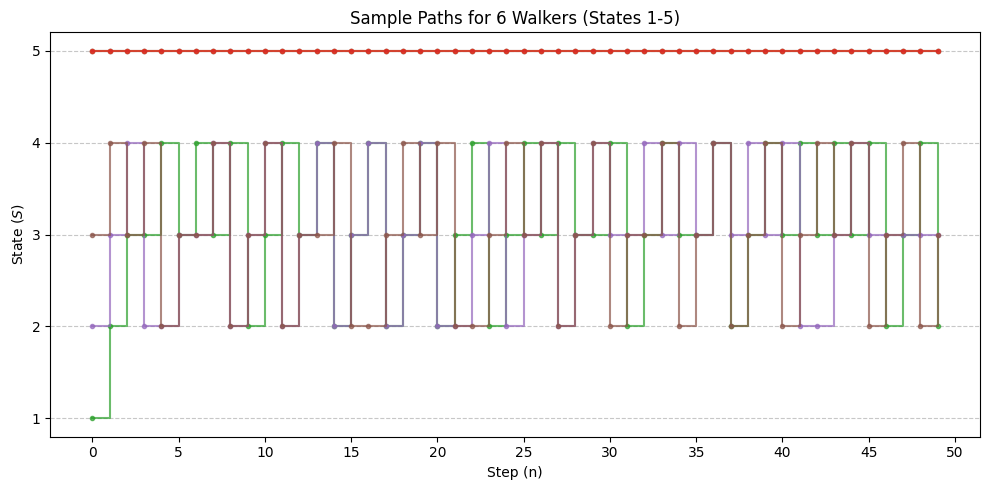

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 6
n_steps = 50

# Llamamos a la función eficiente que definimos arriba
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

plt.figure(figsize=(10, 5))
for i in range(n_samples):
    # El eje X son los pasos (0, 1, 2, ..., n_steps-1)
    abscisas_x = np.arange(n_steps)

    # El eje Y son los estados que ha visitado la trayectoria i
    ordenadas_y = trayectorias[i, :]

    plt.step(abscisas_x, ordenadas_y, where='post', alpha=0.7, marker='o', markersize=3)

m = P.shape[0]
plt.yticks(np.arange(1, m+1))
plt.xticks(np.arange(0, n_steps + 1, 5))
plt.xlabel("Step (n)")
plt.ylabel(r"State ($S$)")
plt.title(f"Sample Paths for {n_samples} Walkers (States 1-5)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Función para obtener la distribución marginal de una MC en un instante dado.

In [ ]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n: instante de tiempo en el que se quiere calcular la distribución marginal. Int.

  Output:
  marginal: distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}). Numpy array con shape (m,).
  """
  # El instante n requiere elevar la matriz P a la potencia n-1
  marginal = pi_sup_1 @ np.linalg.matrix_power(P, n - 1)
  return marginal

### Diapositiva 61

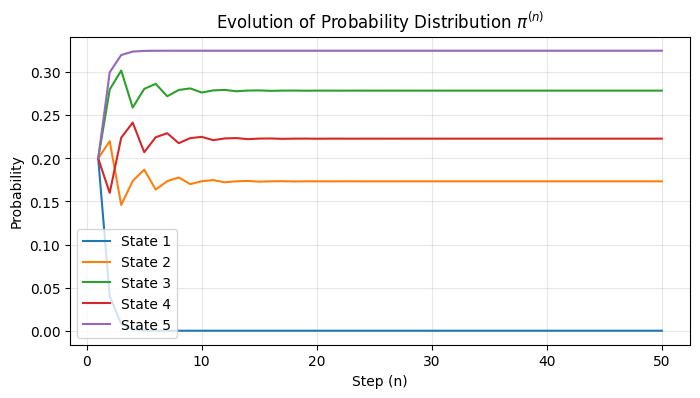

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

# Todos los estados empiezan con la misma probabilidad
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  # Llamamos a la función. Como 'i' va de 0 a 49, pasamos 'i+1' para que sea de 1 a 50
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i + 1)

plt.figure(figsize=(8, 4))
for j in range(m):
    plt.plot(np.arange(1, n_pasos+1), marginales[j,:], label=f"State {j+1}")
plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Diapositiva 63

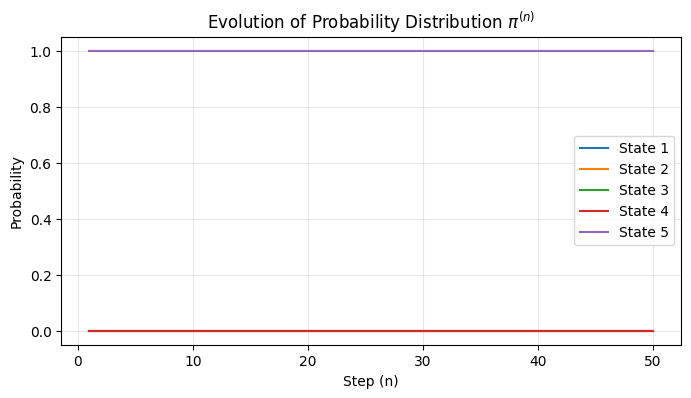

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

# Empezamos con el 100% de probabilidad en el último estado
pi_sup_1 = np.array([0.0, 0.0, 0.0, 0.0, 1.0])

n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  # Misma llamada que antes
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i + 1)

plt.figure(figsize=(8, 4))
for j in range(m):
    # Corregido n_steps por n_pasos para que funcione bien
    plt.plot(np.arange(1, n_pasos+1), marginales[j,:], label=f"State {j+1}")
plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

 ## Función para dibujar el diagrama de transición de estados de una MC.

In [ ]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  pos = nx.circular_layout(G)
  plt.figure(figsize=(8, 6))

  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  edge_labels = nx.get_edge_attributes(G, 'weight')
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("Diagrama de Transición de Estados con Probabilidades")
  plt.show()

### Diapositiva 27

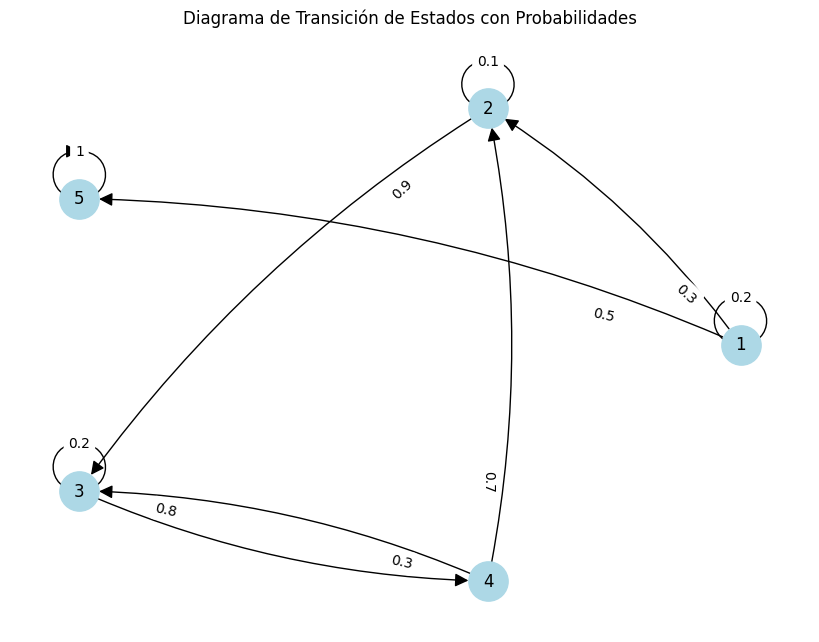

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

states = [1, 2, 3, 4, 5]
dibujar_diagrama_transicion(P, states)

## Función para visualizar la evolución de la distribución marginal de una MC.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
    """
    Función para visualizar la evolución de la distribución marginal para una MC.

    Input:
    P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
    pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
    n_steps: instante de tiempo hasta el que se quiere visualizar. Int.

    Output:
    La función no devuelve nada por "return", simplemente realiza un gráfico.
    """

    m = P.shape[0]

    # Paso 1: crear un array con shape (m, n_steps) y rellenarlo con las marginales
    marginales = np.zeros((m, n_steps))

    # Inicializamos la marginal actual con la distribución inicial
    marginal_actual = pi_sup_1

    for i in range(n_steps):
        marginales[:, i] = marginal_actual
        marginal_actual = marginal_actual @ P

    # Paso 2: Dibujar la trayectoria de cada componente de la marginal.
    plt.figure(figsize=(8, 4))
    for j in range(m):
        plt.plot(np.arange(1, n_steps + 1), marginales[j, :], label=f"Estado {j+1}")

    plt.xlabel("Paso (n)")
    plt.ylabel("Probabilidad")
    plt.title(r"Evolución de la Distribución de Probabilidad $\pi^{(n)}$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

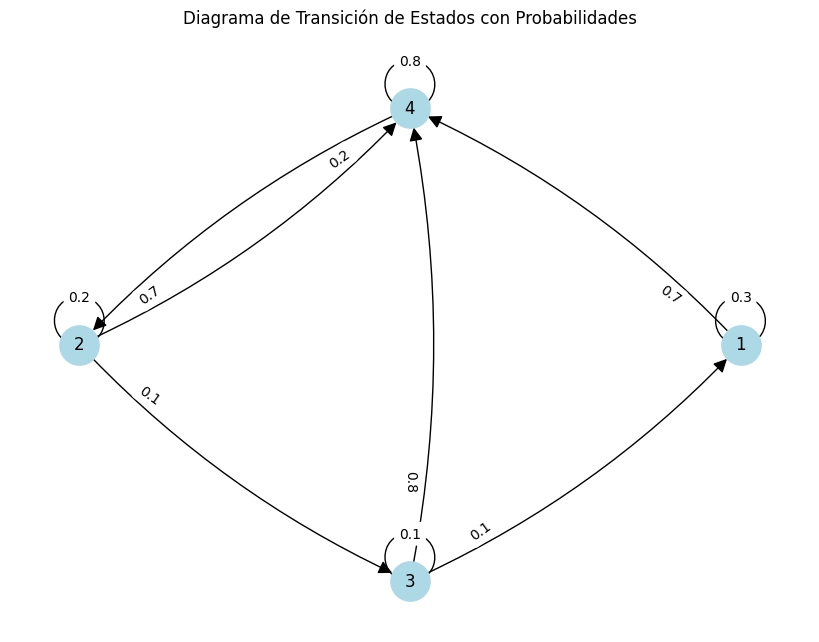

In [ ]:
P = np.array([
    [0.3, 0.0, 0.0, 0.7],
    [0.0, 0.2, 0.1, 0.7],
    [0.1, 0.0, 0.1, 0.8],
    [0.0, 0.2, 0.0, 0.8]
])

dibujar_diagrama_transicion(P, [1,2,3,4])

### Comprobación de convergencia con distribución inicial aleatoria

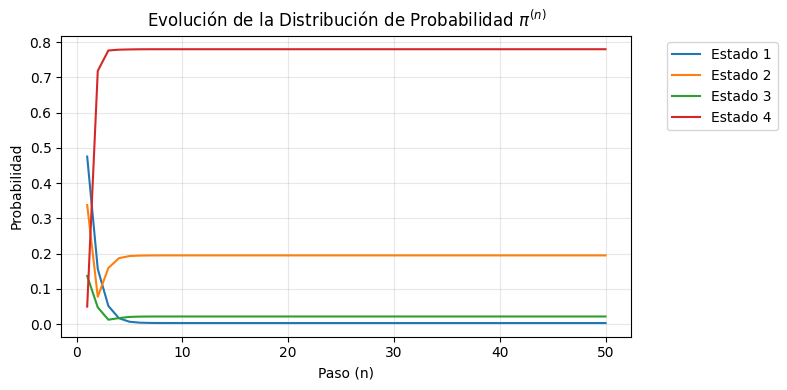

[0.00309598 0.19504644 0.02167183 0.78018576]


In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# 1. Generamos valores aleatorios entre 0 y 1 para cada uno de los 4 estados
pi_sup_1 = np.random.rand(4)

# 2. Normalizamos dividiendo por la suma total para que sumen exactamente 1.0
pi_sup_1 = pi_sup_1 / np.sum(pi_sup_1)

# Llamamos a las funciones previas
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

Efectivamente, queda comprobado que todas terminan en el mismo valor: [0.00309598 0.19504644 0.02167183 0.78018576]

### Visualización (Heatmap) de la matriz $P$

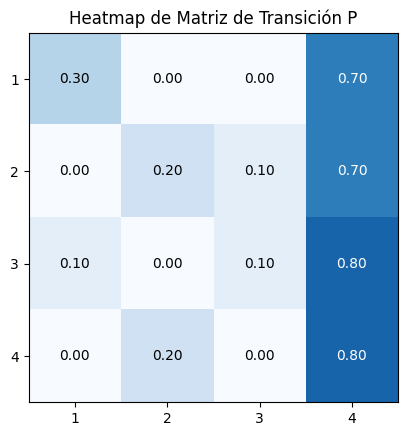

In [ ]:
# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.title("Heatmap de Matriz de Transición P")
plt.show()

El código de color usa blancos para probabilidades nulas o muy bajas, y azules oscuros para probabilidades altas. De un solo vistazo, el azul oscuro de toda la columna 4 revela que el Estado 4 actúa como un atractor, lo que explica por qué la distribución estacionaria acaba concentrando casi un 80% de la probabilidad en ese estado a largo plazo.

### Evolución de $P^n$ y convergencia de las filas

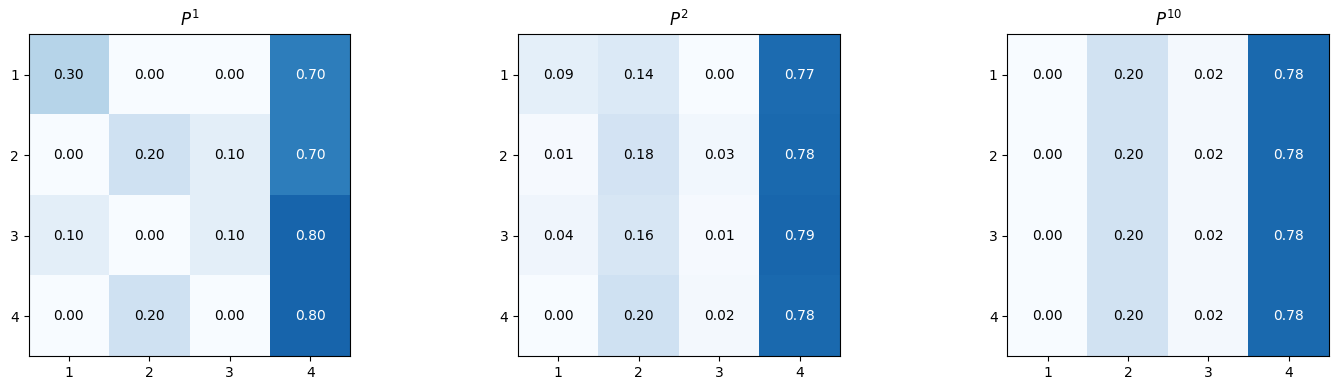

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    # COMPLETAR: Elevamos la matriz P a la potencia n
    Pn = np.linalg.matrix_power(P, n)

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

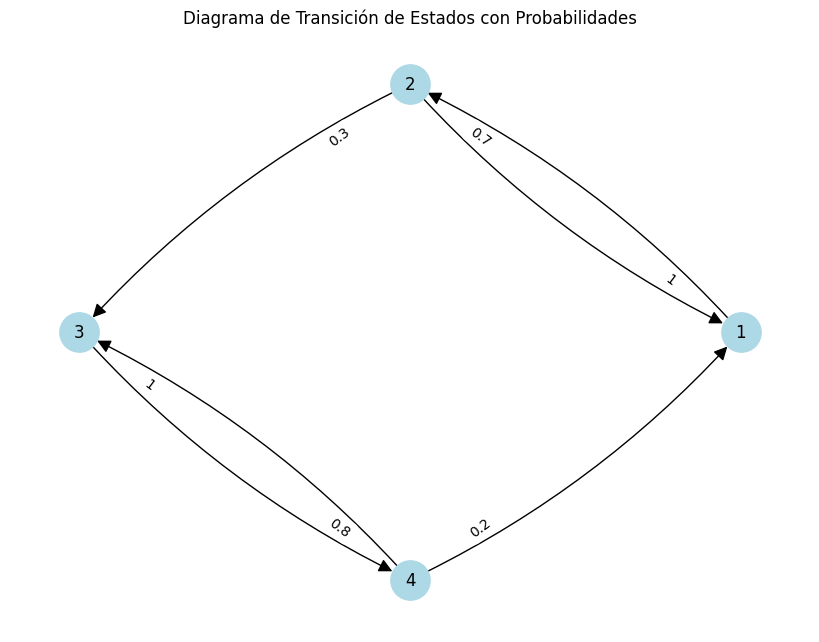

In [ ]:
P = np.array([[0.0, 1.0, 0.0, 0.0],
              [0.7, 0.0, 0.3, 0.0],
              [0.0, 0.0, 0.0, 1.0],
              [0.2, 0.0, 0.8, 0.0]])

# Dibujamos el diagrama de transición (los estados serán 1, 2, 3 y 4)
dibujar_diagrama_transicion(P, np.arange(1, P.shape[0] + 1))

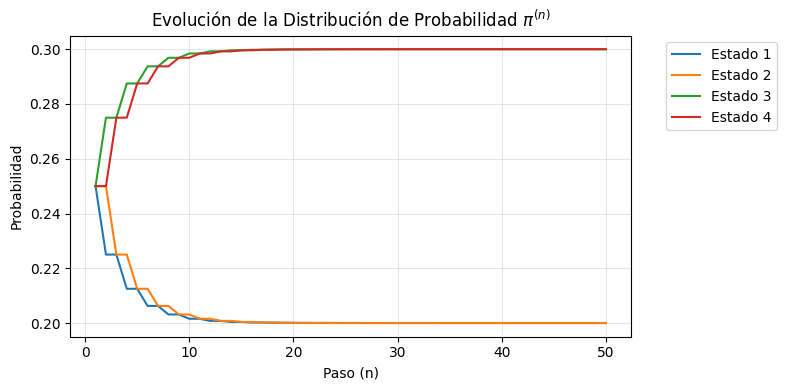

[0.2 0.2 0.3 0.3]


In [ ]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

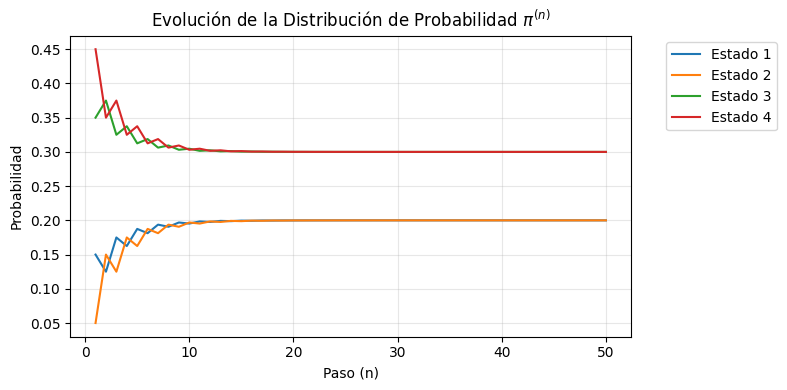

[0.2 0.2 0.3 0.3]


In [ ]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

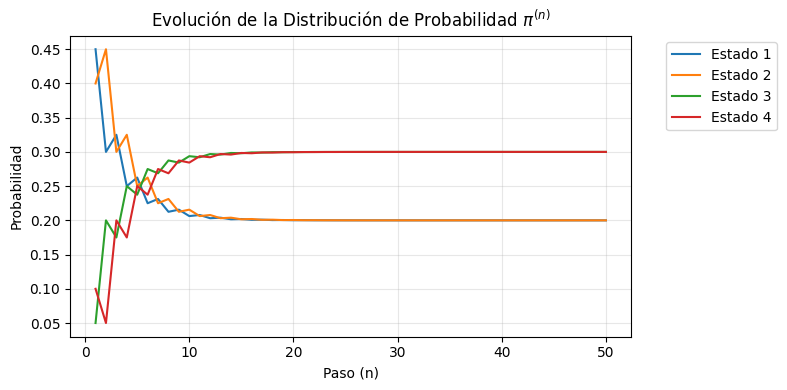

[0.20000001 0.20000001 0.29999999 0.29999999]


In [ ]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

En los tres casos, parece producirse convergencia de la marginal a la distribución [0.2 0.2 0.3 0.3].

### Distribución inicial para que no haya convergencia

Lo que ha ocurrido en esos tres casos previos es que las distribuciones iniciales repartían la probabilidad entre los dos subgrupos cíclicos (los estados impares $\{1, 3\}$ y los pares $\{2, 4\}$) de tal forma que las oscilaciones de la cadena se "cancelaban" al promediarse, estabilizándose visualmente en la distribución estacionaria.

Para demostrar que la cadena es periódica y que el teorema se cumple (es decir, que la convergencia falla en el caso general), solo necesitamos poner toda la probabilidad inicial en un único estado (o en un único subgrupo). Al hacerlo, la cadena se verá obligada a saltar en bloque de un subgrupo a otro, oscilando para siempre sin llegar a aplanarse.

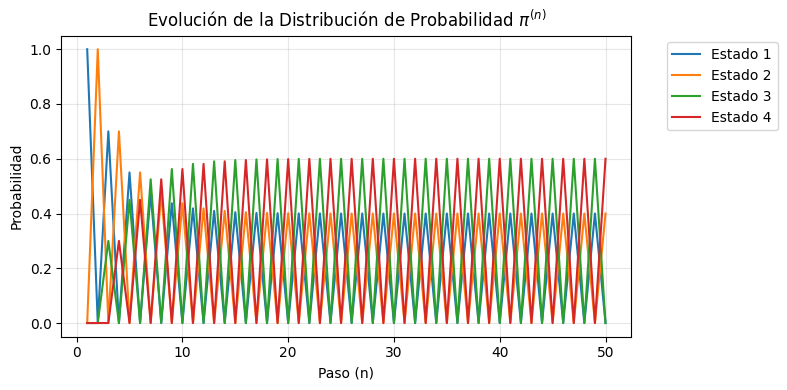

[0.         0.40000004 0.         0.59999996]


In [ ]:
# Concentramos toda la masa de probabilidad en el Estado 1.
# Esto fuerza a la cadena a alternar entre los estados {1,3} y {2,4} eternamente.
pi_sup_1 = np.array([1.0, 0.0, 0.0, 0.0])

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50))

### Función que calcula las proporciones  pi(nsamples,nsteps)  para una trayectoria aleatoria de una MC dada.

In [ ]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.

  Input:

  n_samples: número de trayectorias a simular. Int.
  n_steps: paso hasta el que se quieren calcular las proporciones. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:

  props: Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps. Array de shape (m, n_steps).
  """
  m = P.shape[0]

  # Paso 1: utilizar la función "simular_trayectorias_effic" para simular n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)  # (n_samples, n_steps)

  # Paso 2: compara cada item del array anterior con cada uno de los estados i=1,...,m.
  # Para usar broadcasting, creamos un array 3D de los estados y expandimos las trayectorias.
  estados = np.arange(1, m + 1).reshape(m, 1, 1)             # Shape: (m, 1, 1)
  trayectorias_expandidas = trayectorias[np.newaxis, :, :]   # Shape: (1, n_samples, n_steps)

  is_equal_bool = (trayectorias_expandidas == estados)       # Shape: (m, n_samples, n_steps)

  # Paso 3: hacer la media en la dimensión de "n_samples" (que corresponde a axis=1).
  # En numpy, la media de un array booleano se calcula tratando True como 1 y False como 0.
  props = np.mean(is_equal_bool, axis=1)                     # Shape: (m, n_steps)

  return props

Visualización para la MC aperiódica y unicadenal

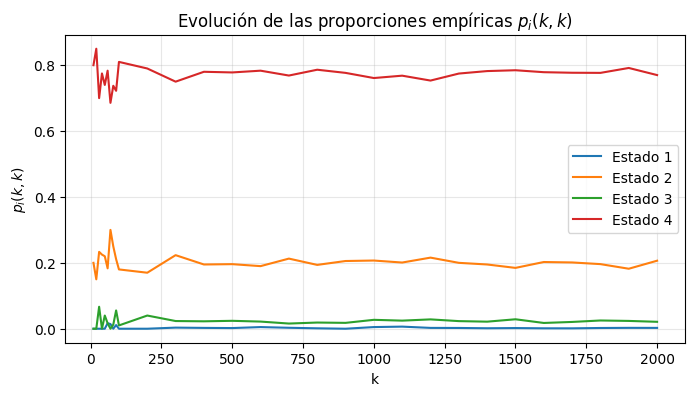

Proporciones empíricas p_i(2000,2000):
[0.0025 0.2065 0.021  0.77  ]

Distribución estacionaria (teórica al paso 50):
[0.00309598 0.19504644 0.02167183 0.78018576]


In [ ]:
# Definimos la MC (nada que completar aquí)
P = np.array([[0.3, 0.0, 0.0, 0.7],
              [0.0, 0.2, 0.1, 0.7],
              [0.1, 0.0, 0.1, 0.8],
              [0.0, 0.2, 0.0, 0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j in range(len(grid)):
    k = grid[j]
    # COMPLETAR: Llamamos a la función con k trayectorias y k pasos, y cogemos la última columna
    props_plot[:, j] = proporciones_empiricas_hasta_cierto_paso(k, k, P, pi_sup_1)[:, -1]

# A continuación se hace el gráfico.
plt.figure(figsize=(8, 4))
for i in range(m):
    plt.plot(grid, props_plot[i, :], label=f"Estado {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolución de las proporciones empíricas $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla los resultados finales
print("Proporciones empíricas p_i(2000,2000):")
print(props_plot[:, -1])
print("\nDistribución estacionaria (teórica al paso 50):")
print(obtener_marginal(P, pi_sup_1, 50))

## Teorema ergódico

### Función que, dada una MC (P y pi_sup_1) y una cantidad de pasos n_steps, calcule las cantidades  qi(n)  para cada  i=1,…,m  y cada  n=1,…,nsteps.

In [ ]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Función que calcula la frecuencia empírica de visitas a cada uno de los estados para una trayectoria de una MC hasta cierto paso.

  Input:
  n_steps: paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:
  frecuencias_hasta_cierto_paso: frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps. Array con shape (m, n_steps)
  """
  m = P.shape[0]

  # Paso 1: simular 1 trayectoria para la MC, hasta el paso n_steps
  # Usamos la función eficiente que definimos antes, con n_samples = 1
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps)  # Shape: (1, n_steps)

  # Paso 2: compara cada valor obtenido con cada uno de los m posibles estados.
  # Creamos un vector columna con los estados posibles
  estados = np.arange(1, m + 1).reshape(m, 1)                      # Shape: (m, 1)

  # Al comparar un array (m, 1) con uno (1, n_steps), el broadcasting de numpy
  # genera automáticamente una matriz de comparaciones de shape (m, n_steps)
  is_equal_bool = (estados == trayectoria)                         # Shape: (m, n_steps)

  # Paso 3: obtener "recuentos_hasta_cierto_paso" sumando acumulativamente las visitas (True = 1)
  # np.cumsum(..., axis=1) va sumando por filas de izquierda a derecha.
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1)   # Shape: (m, n_steps)

  # Paso 4: calcular "frecuencias_hasta_cierto_paso" dividiendo entre el paso actual n.
  # Creamos un vector fila con los divisores: [1, 2, 3, ..., n_steps]
  pasos_n = np.arange(1, n_steps + 1)                              # Shape: (n_steps,)

  # El broadcasting divide cada columna de la matriz de recuentos por su paso correspondiente
  frecuencias_hasta_cierto_paso = recuentos_hasta_cierto_paso / pasos_n  # Shape: (m, n_steps)

  return frecuencias_hasta_cierto_paso

Diagrama de transición de MC aperiódica y unicadenal

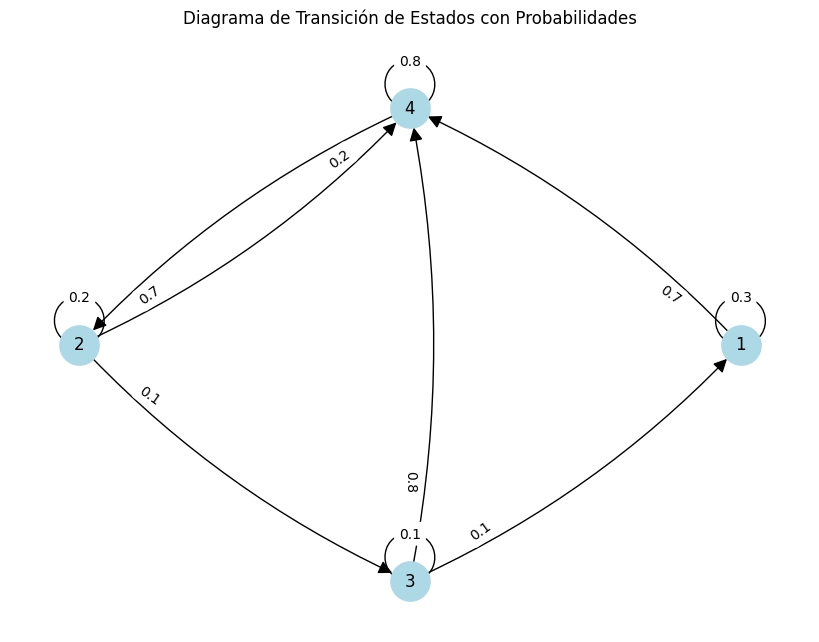

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

### Evolución de cada una de las  qi(n)  cuando  n  crece

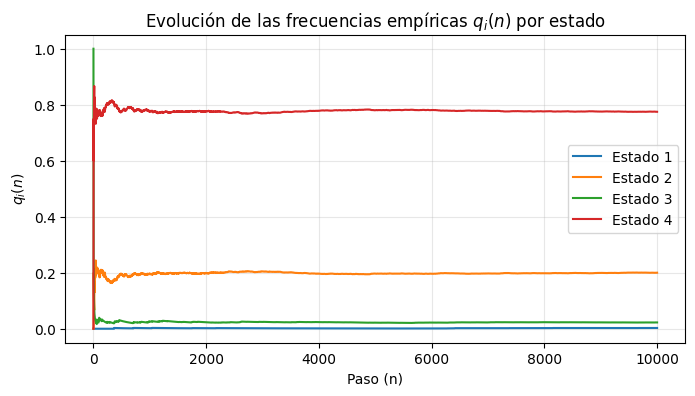

Frecuencias empíricas en el paso 10000:
[0.0027 0.2001 0.0224 0.7748]


In [ ]:
P = np.array([[0.3, 0.0, 0.0, 0.7],
              [0.0, 0.2, 0.1, 0.7],
              [0.1, 0.0, 0.1, 0.8],
              [0.0, 0.2, 0.0, 0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

# COMPLETAR: Obtenemos la matriz de frecuencias llamando a nuestra función
frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # Shape: (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
    # COMPLETAR: Graficamos la fila i-ésima completa (todos los pasos)
    plt.plot(np.arange(1, n_steps + 1), frecs[i, :], label=f"Estado {i+1}")

plt.xlabel("Paso (n)")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolución de las frecuencias empíricas $q_i(n)$ por estado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Frecuencias empíricas en el paso 10000:")
print(frecs[:, -1])

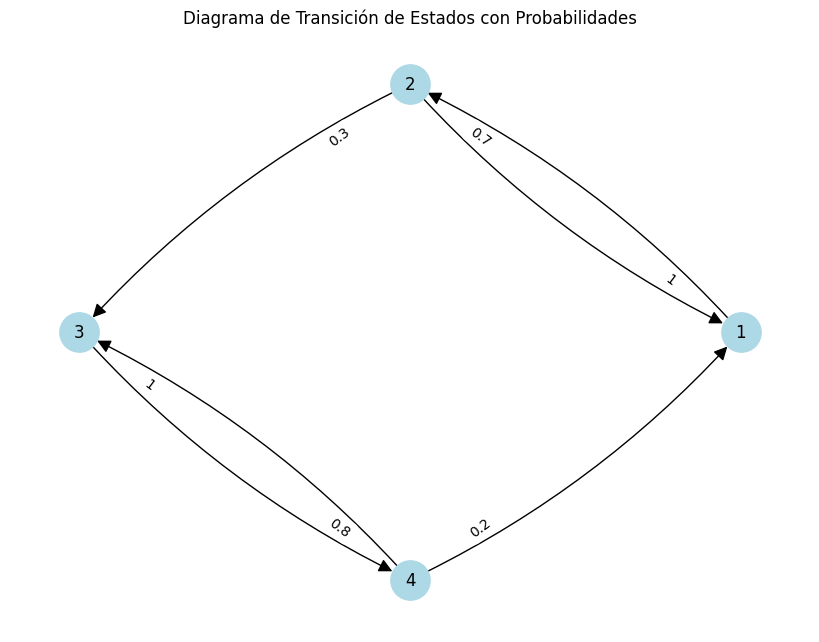

In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

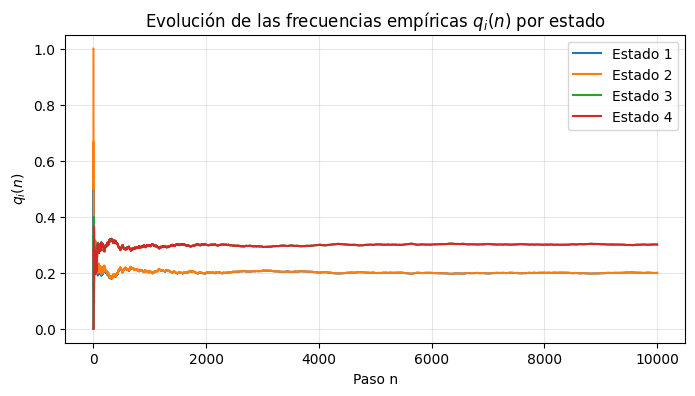

Frecuencias empíricas en el paso 10000:
[0.1993 0.1994 0.3007 0.3006]


In [ ]:
# Definimos la MC periódica y una distribución inicial cualquiera
P = np.array([[0.0, 1.0, 0.0, 0.0],
              [0.7, 0.0, 0.3, 0.0],
              [0.0, 0.0, 0.0, 1.0],
              [0.2, 0.0, 0.8, 0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

# COMPLETAR: Obtenemos la matriz de frecuencias llamando a nuestra función
frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
    # COMPLETAR: Graficamos la fila i-ésima completa
    plt.plot(np.arange(1, n_steps + 1), frecs[i, :], label=f"Estado {i+1}")

plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolución de las frecuencias empíricas $q_i(n)$ por estado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Frecuencias empíricas en el paso 10000:")
print(frecs[:, -1])